# Deep Dive Analysis: Momentum Search vs Static Markowitz (2025)

Notebook ini membandingkan strategi **AI + Momentum + Graph** (Top 15 & Top 30) dengan **Static Markowitz Baseline**.

**Tujuan:**
1. Membuktikan keunggulan *regime-switching AI* dan *momentum filtering* dibandingkan strategi beli-dan-tahan (*buy-and-hold*) Markowitz tradisional.
2. Melihat dampak pembatasan universe aset (Top 15 vs Top 30) terhadap outperformansi di atas baseline.
3. Visualisasi perbandingan efisiensi portofolio di tahun 2025.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from scipy.optimize import minimize
import networkx as nx
from sklearn.metrics import fbeta_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette("husl")

SEED = 42
np.random.seed(SEED)

print("✓ Environment Ready for Deep Baseline Comparison!")

✓ Environment Ready for Deep Baseline Comparison!


## 1. Load Data & Setup

In [2]:
# Load cryptocurrency data
file_path = '../experiment_nextLevel2/dataset_2023_2025.xlsx'
data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

print(f"Data: {len(data)} rows, {len(data.columns)} assets")

Data: 990 rows, 25 assets


## 2. Model Training & Probabilities

In [3]:
# Prepare features
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

# Train model (up to 2024)
X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, 
                              random_state=SEED, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

opt_t = 0.52
all_probs = pd.Series(xgb_model.predict_proba(features.dropna())[:, 1], index=features.dropna().index)
all_probs = all_probs.reindex(returns.index, method='ffill').fillna(method='bfill')

print(f"✓ AI Probabilities Ready.")

✓ AI Probabilities Ready.


## 3. Simulation Engines

In [4]:
def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu = selected_returns.mean() * 252
    sigma = selected_returns.cov() * 252
    num_assets = len(mu)
    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        return -(ret / risk) if risk > 0.0001 else 0
    res = minimize(objective, [1./num_assets]*num_assets, method='SLSQP', 
                   bounds=tuple((0, 1) for _ in range(num_assets)), 
                   constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def get_assets_graph_selection(returns_window, corr_threshold=0.4, top_n=25, strategy_type='diversify'):
    momentum_assets = returns_window.mean().sort_values(ascending=False).head(top_n).index
    returns_mom = returns_window[momentum_assets]
    corr_mat = returns_mom.corr()
    G = nx.Graph()
    G.add_nodes_from(momentum_assets)
    for i, a1 in enumerate(momentum_assets):
        for a2 in momentum_assets[i+1:]:
            if strategy_type == 'diversify':
                if abs(corr_mat.loc[a1, a2]) > corr_threshold: G.add_edge(a1, a2)
            else:
                if abs(corr_mat.loc[a1, a2]) < corr_threshold: G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))

def run_simulation_ai_momentum(test_dates, returns, ai_probs, threshold, market_idx, top_n, strategy_type, fee=0.0025):
    val = 100.0; history = [val]; dates = [test_dates[0]]
    current_weights = {}; risk_status = False; days_since_rebal = 999
    market_ma = market_idx.rolling(window=200).mean()

    for i, date in enumerate(test_dates[:-1]):
        prob = ai_probs.loc[date]
        prev_risk = risk_status
        if not risk_status and prob > (threshold + 0.05): risk_status = True
        elif risk_status and prob < (threshold - 0.05): risk_status = False
        if market_idx.loc[date] > market_ma.loc[date]: risk_status = True
            
        target_weights = current_weights.copy()
        if not risk_status:
            target_weights = {'CASH': 1.0}; days_since_rebal = 0
        else:
            if (risk_status != prev_risk) or days_since_rebal >= 20:
                try:
                    loc_idx = returns.index.get_loc(date)
                    window = returns.iloc[max(0, loc_idx-60):loc_idx]
                    selected = get_assets_graph_selection(window, top_n=top_n, strategy_type=strategy_type)
                    if selected: target_weights = optimize_markowitz(window[selected]); days_since_rebal = 0
                except: pass
        
        days_since_rebal += 1
        turnover = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in set(target_weights)|set(current_weights))
        val -= val * turnover * fee
        next_date = test_dates[i+1]
        day_ret = 0; new_drifted = {}
        if 'CASH' in target_weights: 
            new_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                r = returns.loc[next_date, asset] if next_date in returns.index else 0
                day_ret += w * r
                new_drifted[asset] = w * (1 + r)
        val *= (1 + day_ret); history.append(val); dates.append(next_date)
        current_weights = {k: v/sum(new_drifted.values()) for k, v in new_drifted.items()} if sum(new_drifted.values()) > 0 else new_drifted
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

def run_simulation_static(test_dates, returns):
    val = 100.0; history = [val]; dates = [test_dates[0]]
    for i, date in enumerate(test_dates[:-1]):
        day_ret = returns.loc[test_dates[i+1]].mean()
        val *= (1 + day_ret); history.append(val); dates.append(test_dates[i+1])
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

## 4. Run Experiment (2025)

In [5]:
test_dates_2025 = returns.loc[returns.index.year == 2025].index
scenarios = [15, 30]
results = {}
metrics = []

print("Simulating Static Baseline...")
val_static = run_simulation_static(test_dates_2025, returns)
results['Static'] = val_static

for n in scenarios:
    print(f"Simulating Scenario: Top {n} Momentum Assets...")
    v_div = run_simulation_ai_momentum(test_dates_2025, returns, all_probs, opt_t, market_index, n, 'diversify')
    v_cls = run_simulation_ai_momentum(test_dates_2025, returns, all_probs, opt_t, market_index, n, 'cluster')
    results[f'Div_Top{n}'] = v_div
    results[f'Cls_Top{n}'] = v_cls

# Calculate All Metrics
for name, v in results.items():
    ret = (v['Portfolio_Value'].iloc[-1]/100 - 1)*100
    vol = v['Portfolio_Value'].pct_change().std()*np.sqrt(252)*100
    sharpe = ret/vol if vol > 0 else 0
    metrics.append({'Strategy': name, 'Return (%)': ret, 'Sharpe': sharpe, 'Volatility (%)': vol})

m_df = pd.DataFrame(metrics)
print("✓ Experiment Complete.")

Simulating Static Baseline...
Simulating Scenario: Top 15 Momentum Assets...
Simulating Scenario: Top 30 Momentum Assets...
✓ Experiment Complete.


## 5. Visualisasi Gabungan: vs Static Baseline

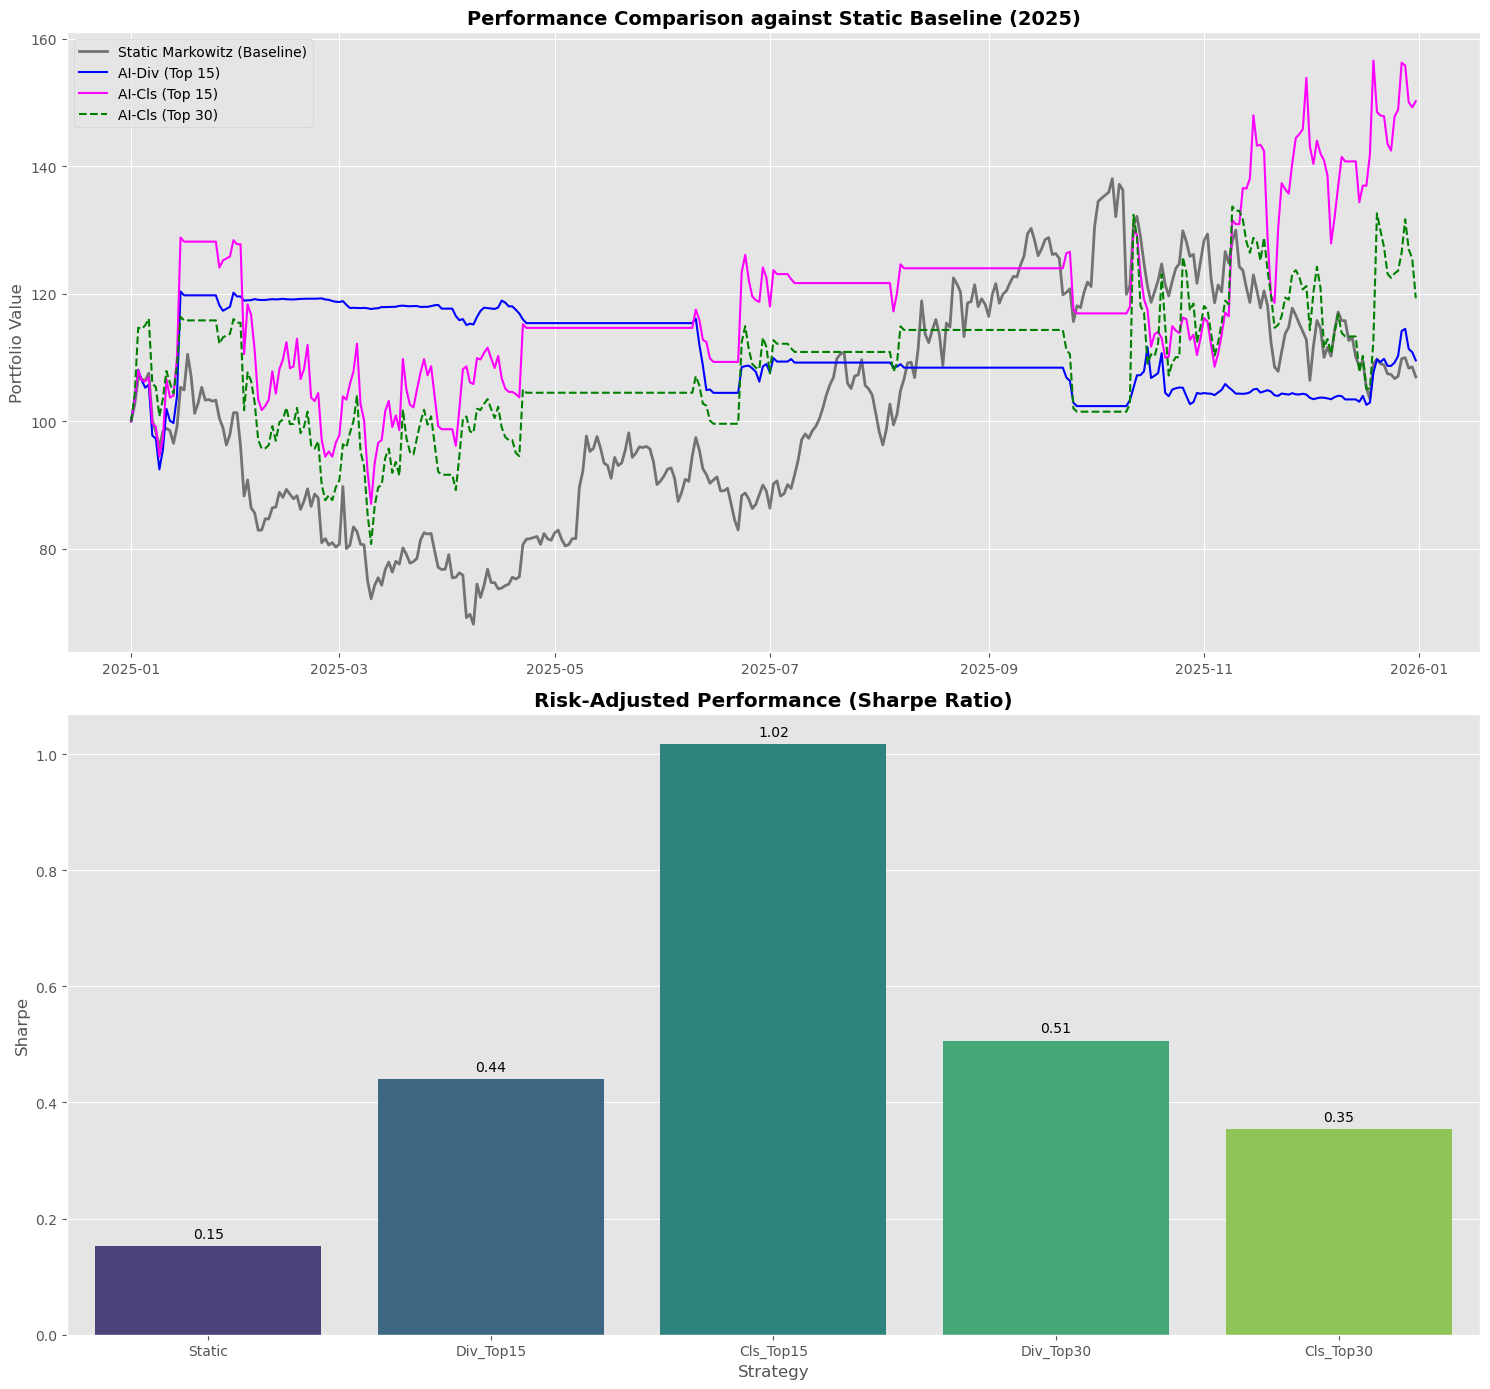

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 14))

# 1. Equity Curve
ax1.plot(results['Static'].index, results['Static']['Portfolio_Value'], label='Static Markowitz (Baseline)', color='black', linewidth=2, alpha=0.5)
ax1.plot(results['Div_Top15'].index, results['Div_Top15']['Portfolio_Value'], label='AI-Div (Top 15)', color='blue')
ax1.plot(results['Cls_Top15'].index, results['Cls_Top15']['Portfolio_Value'], label='AI-Cls (Top 15)', color='magenta')
ax1.plot(results['Cls_Top30'].index, results['Cls_Top30']['Portfolio_Value'], label='AI-Cls (Top 30)', color='green', linestyle='--')

ax1.set_title("Performance Comparison against Static Baseline (2025)", fontweight='bold', fontsize=14)
ax1.set_ylabel("Portfolio Value")
ax1.legend()
ax1.grid(True)

# 2. Sharpe Ratio Comparison
sns.barplot(data=m_df, x='Strategy', y='Sharpe', ax=ax2, palette='viridis')
ax2.set_title("Risk-Adjusted Performance (Sharpe Ratio)", fontweight='bold')
for p in ax2.patches:
    ax2.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.tight_layout()
plt.savefig('momentum_vs_static_2025.png')
plt.show()

## 6. Kesimpulan Perbandingan

Gunakan data di atas untuk mengevaluasi:
1. Apakah strategi dinamis ini mengalahkan *Buy-and-Hold* di tahun 2025?
2. Berapa persentase *outperformance* (Alpha) yang dihasilkan oleh strategi **AI + Momentum Top 15**?